On DAP, we can't install ipykernel in `.venv`. Thus, we need to apply a different strategy.

* do `unzip -o graph-ensemble.zip` 
If not working, remove `mc rm -rf graph-ensemble` and, then, `unzip graph-ensembles.zip`;
* `deactivate` (the `virtual-env`) such that the standard jupter kernel is selected;
* install via `pip install --editable . --config-settings editable_mode=compat`
* create a cell down here and do `import graph_ensembles` to check for the installation;

Usefull Commands:
* For this project, ```vars``` and ```plots``` are saved in `./outputs`;
* Delete folders on dap: ```mc rm --force --purge folder```
* To save new plots, delete previous ones with
```mc rm --force --purge dap/corealgos/rmilocco/outputs/datasets/ING-Directed```

On local:
* Linux: Zip outside the ``graph-ensembles`` folder: 
<br>```zip -rX graph-ensembles.zip graph-ensembles -x "graph-ensembles/src/graph_ensembles.egg-info/*" ".*" "*/.*" "*/__pycache__/*" "*/sythetic_network/*"```

Run the right install cmd from [pytorch](https://pytorch.org/), based on your architecture

Claim: by reconstructing the unobserved, we may close the gap between the total Page-Rank and Page-Rank only inside the ING-clients

1) Split the nodes into ING (`vI`) and `ROW` (`vR`);

2) Find ``vI`` and ``eI`` as the edges only between. We will cal `intra` (`eI`) edges, `bet` (ING-ROW), `row` (non ING interacting clients); 

4) Calculate the Page-Rank of only the `intra` nodes and compare it with the full graph PR.
Now, we expect that the 2 PR are different. So, help this bias by reconstructing the missing part. Ref [LateX](https://asajadi.github.io/fast-pagerank/) based on [MathWorks](https://www.mathworks.com/content/dam/mathworks/mathworks-dot-com/moler/exm/chapters/pagerank.pdf);

5) Calculate the strengths taking into account also the ING-ROW fluxes, while discarding the self-payments;
6) Freeze the `eI` and fit $\delta$ parameter as 
    * $L_I \stackrel{!}{=} \langle L_I \rangle(\delta_I) := \sum_{i \in I, j \in I} p_{ij}(\delta_I)$;

    * $L^{no-I}_U = L_I + L_{bet} \stackrel{!}{=} L_I + \sum_{i \in I, r \in R} (p_{ir}(\delta_{U}) + p_{ri}(\delta_{U})) $;

    * $L_U = L_I + L_{bet} \stackrel{!}{=} \sum_{(i,j) \in \left\{(I,I),(I,R),(R,I) \right\} } p_{ij}(\delta_{U}) $;

7) Page-Rank (or Influence Vector);

In [ ]:
ciao = 3

In [4]:
# auto-reload the packages at every run
%load_ext autoreload
%autoreload 2

#display all the results not only the last one
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

import os
try:
    corpkey = True if os.environ['DSBOX_USERNAME'] else None
    # %pip install matplotlib pandas scipy tqdm torch torchvision
except:
    corpkey = None

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import graph_ensembles as ge
from graph_ensembles import sparse as sp
import graph_ensembles.utils as utils
import graph_ensembles.dependencies as dep
from graph_ensembles.plots import plotting_functions as plot

# plot.plot_local_fonts(corpkey)
utils._set_mpl_params(fontsize=20)
utils.check_cpu_gpu_with_torch()

dataset_name = "ING" #"recNET"
dataset_direction = "Directed"
id_code, cg_method, year = "grid_id", "random", 2022

ModuleNotFoundError: No module named 'matplotlib'

In [ ]:
# note that inside the kwargs there is a copy of the pdtrans
max_num_entries = None #if corpkey else 3e3 #30e6 # old 1e3
pdtrans, kwargs, total_levels = \
    ge.dataset_loader(dataset_name, dataset_direction = dataset_direction,
                    corpkey = corpkey, id_code = id_code, cg_method = cg_method,
                    year = year, max_num_entries = max_num_entries) #63332573

pdtrans.info()


Reading from local source
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23699 entries, 0 to 23698
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   payer_grid_id           23699 non-null  int64  
 1   payer_naics_code        23699 non-null  int64  
 2   beneficiary_grid_id     23699 non-null  int64  
 3   beneficiary_naics_code  23699 non-null  int64  
 4   amount_euro             23699 non-null  float64
dtypes: float64(1), int64(4)
memory usage: 925.9 KB


Define all the vertex and edges

In [ ]:
e = pdtrans.loc[:, [f'payer_{id_code}', f'beneficiary_{id_code}']]
unique_nodes_from = lambda df: pd.DataFrame(data = np.unique(df.to_numpy().ravel('K')), columns = ["id"])
v = unique_nodes_from(e) # = 1 column DataFrame with "id" the node label, whereas the index is the incresing integer node-index
e = pdtrans.iloc[:, ::2] # payer, beneficiary, amount_euro
e.columns = ["src", "dst", "amount"] 

e.head()
print(f'-v.shape: {v.shape}',)

,src,dst,amount
0,0,3,31967.586921
1,0,4,11555.933814
2,0,11,13567.051038
3,0,16,3685.056928
4,0,24,169468.484026


-v.shape: (800, 1)


Create Full Graph

In [ ]:
pr_name = "page_rank"
kwargs_graph = {'name' : 'ING', 'level' : 0, 'corpkey' : corpkey, "_pr_name" : pr_name}
g = sp.graphs.DiGraph(v, e, **kwargs_graph)
# g.load_or_create_degrees()

# del pdtrans

In [ ]:
g._kwargs_pr = {"p" : 0.85, "max_iter" : 200, "tol" : 1e-06}
g._pr = g.pagerank_power(**g._kwargs_pr)
# g.save_vars()

Create a split of ``v`` into `vI`

Fit the `delta_intra`, for a splitting

In [ ]:
# NB: the vars are not saved since I commented save_vars, savetxt and makedirs

In [ ]:
from tqdm import trange
from itertools import product

# vsplits, intra_sizes = [0], sorted([.2,.5,.8])
vsplits, intra_sizes = [0], sorted([.2])

x0 = [1.8996372e-17]
num_sigmas = 2

# sample arguments
num_graph_samples_per_vsplit = 10
chunk_row_size = 2000
measures = ["_pr", "_topN_overlap_pr", "_topN_tot_rel_err", "_out_degree", "_in_degree",]
rtol = 1e-8
fit_methods = ["num_edges_intra"] #["num_edges_" + i for i in ["intra", "intra_bet"]] #

for intra_size_vsplit in product(intra_sizes, vsplits):
    intra_size, vsplit = intra_size_vsplit

    gI, vI, eI, idx_intra_nodes, unsampled_vI, frozen_edges = g.vsplit_intra_and_calculate_measures(v, e, intra_size, vsplit, kwargs_graph, measures)

    # create the model kwargs
    kwargs_model = kwargs_graph.copy()
    kwargs_model.update({"name" : "MultiScaleMod", "intra_size" : intra_size,
                        "prop_out_I" : g.out_strength(), "prop_in_I" : g.in_strength(),
                        "prop_out_R" : np.array([0]), "prop_in_R" : np.array([0]),
                        "num_sigmas" : num_sigmas
                        })

    # since intra_sizes are sorted, this line changes only the last iteration
    fit_methods = ["num_edges_intra"] if intra_size == 1 else fit_methods 
    
    for fit_method in fit_methods:
        print(f'\n-Dealing with intra_size, vsplit, fit_method {intra_size, vsplit, fit_method}',)

        # vR and num_edges_bet are needed for the fitting procedure
        vR, num_edges = g.vsplit_row(v, vI, e, idx_intra_nodes, gI.num_edges(), fit_method)
        
        # update the model kwarg with the current fit_method
        kwargs_model.update({"fit_method" : fit_method, "num_edges" : num_edges})

        # create the model and fit it
        model = sp.ScaleInvariantModel.initialize_model(g, gI, vR, kwargs_model)
        num_start_graph = model.set_ensemble_variables(measures, num_graph_samples_per_vsplit)
        model.load_or_fit(x0 = x0[0], maxiter = 30, verbose = 2)

        # if intra_size < 1, set the right strengths to predict the full-network
        if intra_size < 1: model.set_num_vertices_out_in_strengths_to(g)

        print(f'\n-For vsplitting vsplit {vsplit}: {num_start_graph} graphs already sampled, {np.clip(num_graph_samples_per_vsplit - num_start_graph, 0, None)} remaining')

        # send variables (model.params, ...) to cuda:0
        unsampled_vI = model.send_variables_to_gpu(unsampled_vI)

        # def var for model vars
        mod_vars = model.__dict__
        
        # Note: the seed = vsplit only works for solo-agent. The graph-sampling is parallelized, so it would be random even if vsplit specified.
        # That's why .sample() has graph_idx as argument
        # set graph_idx = 0, since if all the graphs are already sampled in the next calculations it will have a number different to None
        for graph_idx in trange(num_start_graph, num_graph_samples_per_vsplit, 
                        desc=f"-Total progress {int(np.round((vsplit+1)/len(vsplits) * 100))}%, Inner Graph Sampling", position = 0, leave= True):

            # sample
            gs = model.sample(ref_g = g, unsampled_vI = unsampled_vI, frozen_edges = frozen_edges, 
                            graph_idx = graph_idx, chunk_row_size = chunk_row_size)
            gs.calculate_measures(g, measures)
            gs.set_pr_on_I(gI)
            gs.topN_overlap_pr_tot_rel_err(g, gI)
            
            if not corpkey:
                gs.save_vars(name = f"graph{gs.graph_idx}")
            
            # save the ensemble average and std for every measures on the model class
            for m in measures:
                if num_start_graph == 0 and graph_idx == 0:
                    prev_mean, prev_std = 0, 0
                else:
                    # 1st cycle set the mod_vars to previously loaded meas
                    if graph_idx == num_start_graph:
                        mod_vars[f"prev{m}"], mod_vars[f"prev{m}_std"] = mod_vars[m].copy(), mod_vars[m+"_std"].copy()
                    prev_mean, prev_std = mod_vars[f"prev{m}"], mod_vars[f"prev{m}_std"]
                mod_vars[m], mod_vars[m+"_std"] = \
                    model.recursive_mean_std(graph_idx, prev_mean, prev_std, gs.__dict__[m])

                        
            # create 10 snapshot of the sampling vars and plots
            num_sampled_graphs = graph_idx + 1
            step = num_graph_samples_per_vsplit // 10
            if num_sampled_graphs % step == 0 and num_sampled_graphs > 1: # num_sampled_graphs == num_graph_samples_per_vsplit: #
                
                # save the mean and std as [[mean],[std]]
                if not corpkey:
                    for m in measures:
                        fname = model.vars_dir_ensembles + f"/{m}/num_samples_{num_sampled_graphs}.csv"
                        np.savetxt(fname, X = np.vstack((mod_vars[m], mod_vars[f"{m}_std"])))

                # generate the plot of page-ranks
                utils.set_model_pr_on_I(model, gI)

                # rescale the internal page-rank only in the last step
                if num_sampled_graphs == num_graph_samples_per_vsplit:
                    gI.rescale_pr_with(model, scaler = True)

                num_bins = int(np.sqrt(model.num_vertices))
                plot.pr_on_internal_nodes(model, g, gI, num_bins)
                plot.pr_on_internal_nodes_vs_rank(model, g, gI)
            
            # redefine prev pr and std
            for m in measures:
                mod_vars[f"prev{m}"] = mod_vars[m].copy()
                mod_vars[f"prev{m}_std"] = mod_vars[m+"_std"].copy()
        
        # compute the expected degree and plt them
        utils.set_model_pr_on_I(model, gI)
        unsampled_vI = model.send_variables_to_cpu(unsampled_vI)
        _ = model.expected_degree(unsampled_vI, gI)
        plot.ccdf_deg_out_in(g, gI, model)

        g.topN_overlap_pr_deg_stre(gI)
        g.topN_overlap_pr_deg_stre(gI, model)

        # old plots
        # model.topN_overlap_pr_tot_rel_err_over_mean(g, gI)
        # plot.topN_overlap_pr(gI, model)
        # plot.topN_overlap_pr_tot_rel_err(gI, model)
        # plot.topN_overlap_pr_tot_rel_err_on_avg_pr(g, gI, model)
        # plot.exp_deg_out_in(g, gI, model)
        # plot.annd_vs_deg(g, gI, model, measures)

        break


-Dealing with intra_size, vsplit, fit_method (0.2, 0, 'num_edges_intra')
-Load the parameter enforcing num_edges_intra -> param: [1.02673373e-08]

-For vsplitting vsplit 0: 10 graphs already sampled, 0 remaining


-Total progress 100%, Inner Graph Sampling: 0it [00:00, ?it/s]


In [ ]:
[x for x in model.__dict__ if "overlap" in x]

['_topN_overlap_pr',
 '_topN_overlap_pr_std',
 '_topN_overlap_out_degree_on_I',
 '_topN_overlap_in_degree_on_I']

ValueError: x and y must be the same size

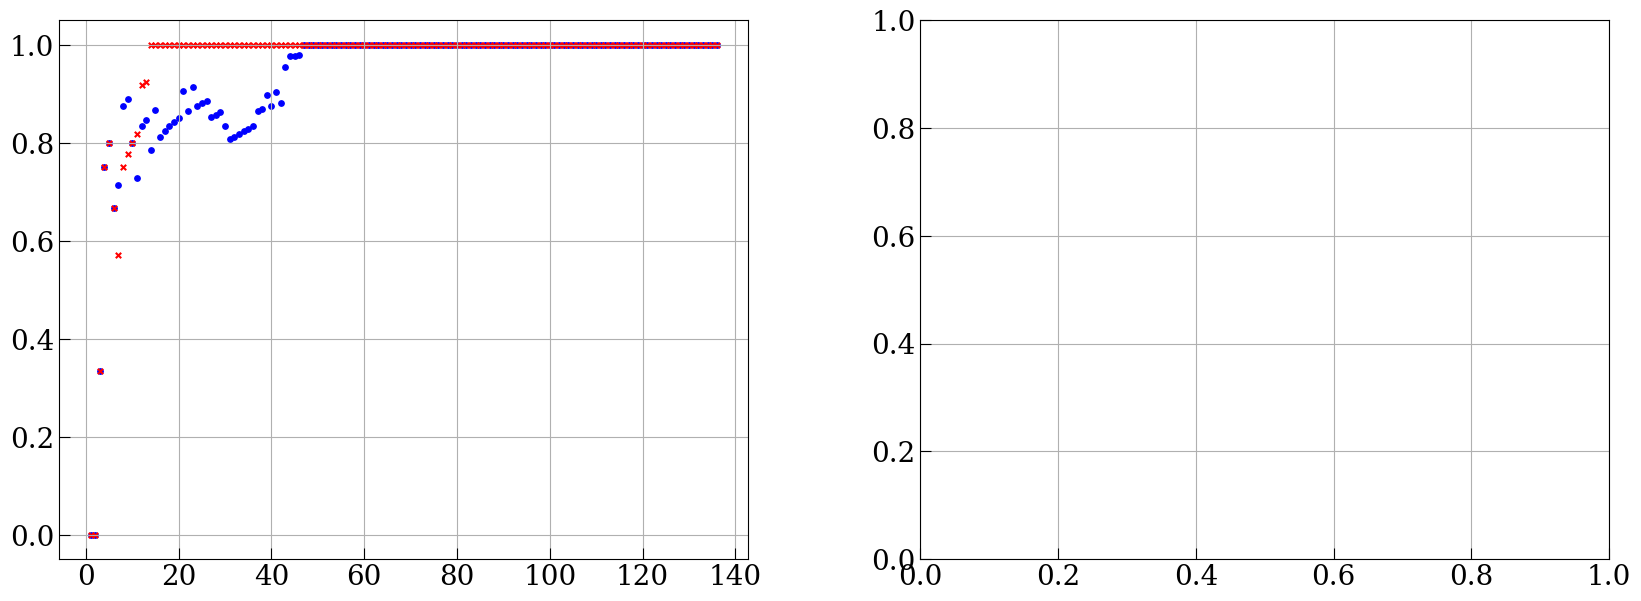

In [48]:
fig, axs = plt.subplots(1, 2, figsize = (20,7))
axis_scale = 'log'
obs_s, exp_s = 15, 15

x = np.arange(1, len(gI._topN_overlap_out_degree) + 1)
axs[0].scatter(x, g._topN_overlap_out_degree_on_I, marker = 'o', color = 'b', s = obs_s, label = '')
axs[0].scatter(x, gI._topN_overlap_out_degree, marker = 'x', color = 'r', s = exp_s, label = '')
axs[0].scatter(x, model._topN_overlap_out_degree_on_I, marker = 'x', color = 'r', s = exp_s, label = '')
axs[0].scatter(x, g._topN_overlap_out_strength_on_I, marker = 'x', color = 'r', s = exp_s, label = '')

axs[0].set(xscale = axis_scale, yscale = axis_scale, xlabel = '', ylabel = '',)
axs[0].legend()
axs[0].set_axisbelow(True)
axs[0].grid(True)

axs[1].scatter(x, g._topN_overlap_in_degree_on_I, marker = 'o', color = 'b', s = obs_s, label = '')
axs[1].scatter(x, gI._topN_overlap_in_degree,  marker = 'x', color = 'r', s = exp_s, label = '')
axs[1].set(xscale = axis_scale, yscale = axis_scale, xlabel = '', ylabel = '',)
for i, ax in enumerate(axs):
    ax.legend()
    ax.set_axisbelow(True)
    ax.grid(True)

In [15]:
[x for x in g.__dict__ if "overlap" in x]

['_topN_overlap_out_degree_on_I',
 '_topN_overlap_in_degree_on_I',
 '_topN_overlap_out_strength_on_I',
 '_topN_overlap_in_strength_on_I']

In [ ]:

def topN_overlap_pr_deg_stre(model, g, gI):

    # topN_overlap btw pr and out/in deg
    internal_nodes = gI.internal_nodes
    
    # ground truth
    topN_overlap_pr_out_in_degree(g, internal_nodes=internal_nodes)
    topN_overlap_pr_out_in_strengths(g, internal_nodes=internal_nodes)

    # internal graph out/in degree
    topN_overlap_pr_out_in_degree(g, gI, internal_nodes=internal_nodes)

    # model out/in degree
    topN_overlap_pr_out_in_degree(g, model, internal_nodes=internal_nodes)

In [11]:
topN_overlap_pr_deg_stre(model, g, gI)

In [ ]:
def topN_by_rank(arr):
    """
    Return a list containing the topN@K, where K is the placement in the rank.
    E.g. K = 3, provides the 1st, 2nd and 3rd classified nodes
    """
    # arr: 1D numpy array of values
    uniq_vals = np.unique(arr)[::-1]  # descending order
    return [np.where(arr >= val)[0] for val in uniq_vals]

def overlap_2_meas(true_meas, est_meas):
    """
    Returns the overlap at topN among the true_meas and est_meas
    """

    true_len, est_len = len(true_meas), len(est_meas)
    overlap_ = []
    for l in range(max(true_len, est_len)):
        i,j = min(l, true_len-1), min(l, est_len-1)
        true_meas_i, est_meas_j = set(true_meas[i]), set(est_meas[j])

        overlap_ij = len(true_meas_i & est_meas_j) / len(true_meas_i) 
        overlap_.append(overlap_ij)

    return overlap_

def overlap_g_pr_on_I(est_meas):
    return overlap_2_meas(g._topN_pr_on_I, est_meas)

def overlap_pr_out_in_measures(self, g, measures):
    """
    Calculate the Overlap between the out/in deg rankings.
    The function is abstract so refer to the Example for a better understanding of the passages.
    Indeed, to host every measure and class we did self_dict = self.__dict__. In the example, instead, there is a practical application for out_degree and gI
    self: gI (internal) or g itself

    Example:
    gI._topN_out_degree = topN_by_rank(gI._out_degree)
    gI._overlap_out_degree = overlap_g_pr_on_I(gI._topN_out_degree)
    """
    overlap_g_pr_on_I = lambda est_meas: overlap_2_meas(g._topN_pr_on_I, est_meas)
    
    for meas in measures:
        self_dict = self.__dict__

        # calculate the topN of the respective meas
        self_dict["_topN"+meas] = topN_by_rank(self_dict[meas])

        # calculate the overlal between the topN page-rank on I and the topN of the measure
        self_dict["_overlap"+meas] = overlap_g_pr_on_I(self_dict["_topN"+meas])

def overlap_pr_out_in_degree(self, g = None, internal_nodes = None):
    """
    Overlap btw the PR-ground-truth and the out/in degrees
    """

    # if g == None, then self must equal g. So, g = self
    if g == None:
        g = self

    if self.graph_kind == "intra":
        degree_measures = ["_out_degree", "_in_degree"]
    else:
        degree_measures = ["_out_degree_on_I", "_in_degree_on_I"]

        if not hasattr(self, "_out_degree_on_I"):
            self._out_degree_on_I = self._out_degree[internal_nodes]
            self._in_degree_on_I = self._in_degree[internal_nodes]


    return overlap_pr_out_in_measures(self, g, degree_measures)

def overlap_pr_out_in_strengths(self, g = None, internal_nodes = None):
    """
    Calculate the Overlap Between the PR of self and 
    """
    # if g == None, then self must equal g. So, g = self
    if g == None:
        g = self

    if not hasattr(g, "_out_strength_on_I"):
        g._out_strength_on_I = g._out_strength[internal_nodes]
        g._in_strength_on_I = g._in_strength[internal_nodes]

    return overlap_pr_out_in_measures(self, g, measures = ["_out_strength_on_I", "_in_strength_on_I"])

def overlap_pr_deg_stre(model, g, gI):

    # overlap btw pr and out/in deg
    internal_nodes = gI.internal_nodes
    
    # ground truth
    overlap_pr_out_in_degree(g, internal_nodes=internal_nodes)
    overlap_pr_out_in_strengths(g, internal_nodes=internal_nodes)

    # internal graph out/in degree
    overlap_pr_out_in_degree(gI, g, internal_nodes=internal_nodes)

    # model out/in degree
    overlap_pr_out_in_degree(model, g, internal_nodes=internal_nodes)